# Cardiovascular Disease Detector

In this notebook we are going to see how can we predict if a person is suffering from CVD or not, by looking at their clinical data, like Blood Pressure, etc.

The dataset is taken from Kaggle, https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data

## Features

* Age | Objective Feature | age | int (days)
* Height | Objective Feature | height | int (cm) |
* Weight | Objective Feature | weight | float (kg) |
* Gender | Objective Feature | gender | categorical code |
* Systolic blood pressure | Examination Feature | ap_hi | int |
* Diastolic blood pressure | Examination Feature | ap_lo | int |
* Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
* Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
* Smoking | Subjective Feature | smoke | binary |
* Alcohol intake | Subjective Feature | alco | binary |
* Physical activity | Subjective Feature | active | binary |
* Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

## Importing Packages/Libraries

In [30]:
# Regular EDA and plotting libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Models from sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay

## Basic EDA

### Data Overview

In [2]:
# Importing csv 

data = pd.read_csv("../dataset/cardio_train.csv")
data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Number of Rows and Columns

print(f"Number of Rows and Columns: {data.shape}")

Number of Rows and Columns: (70000, 13)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
# Checking for null values

data.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
# Deeper insight on our data

data.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


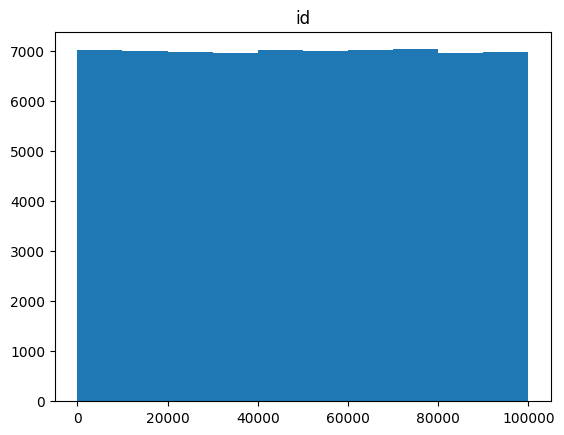

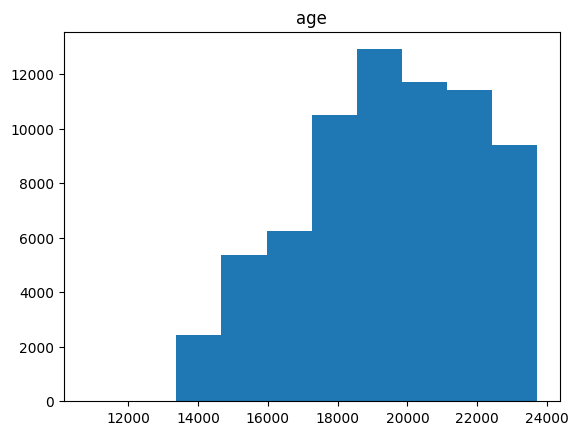

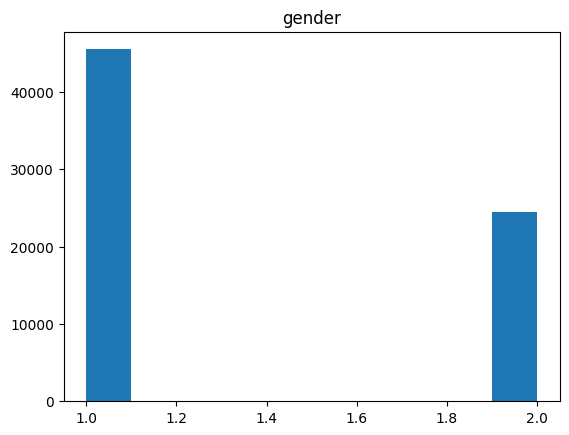

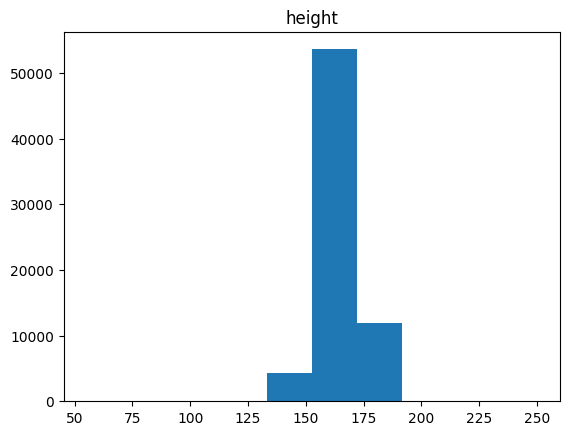

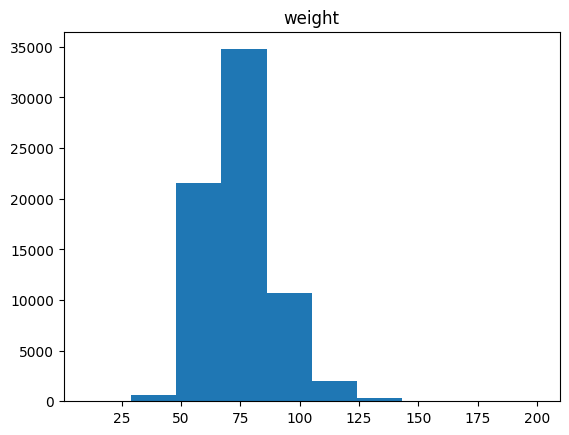

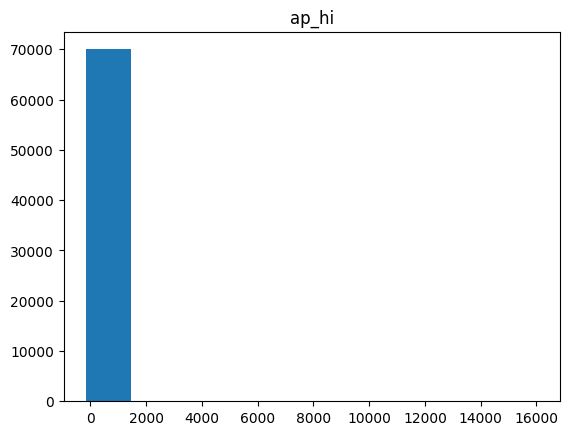

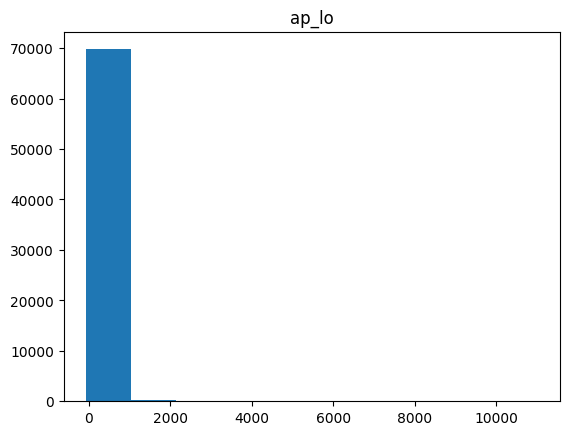

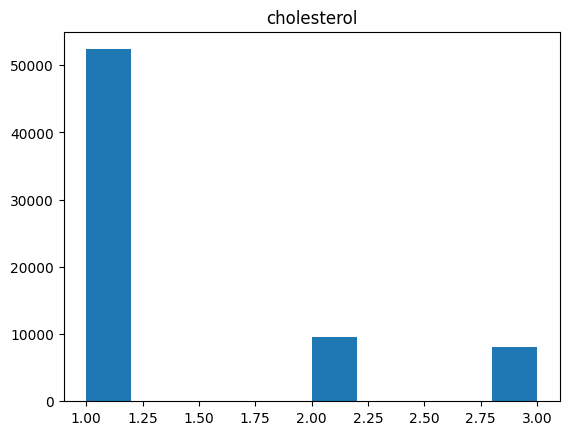

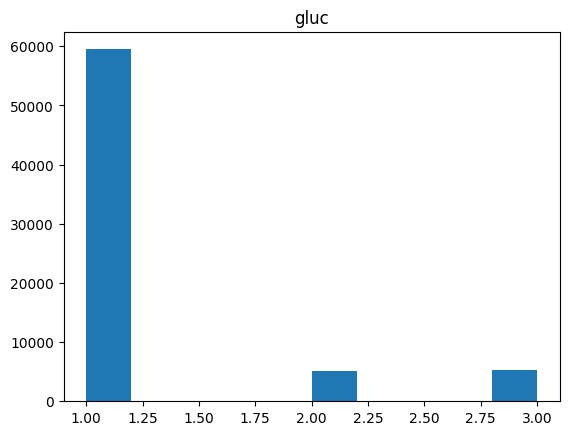

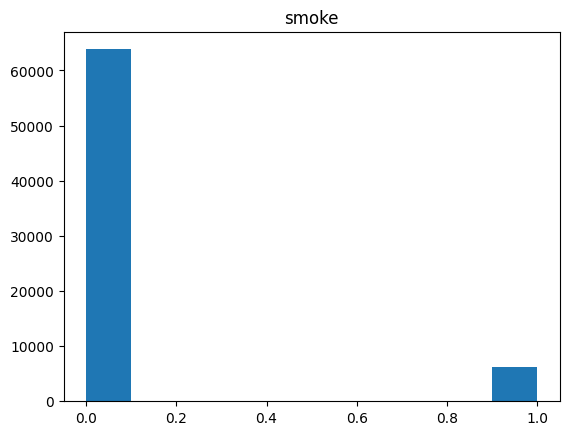

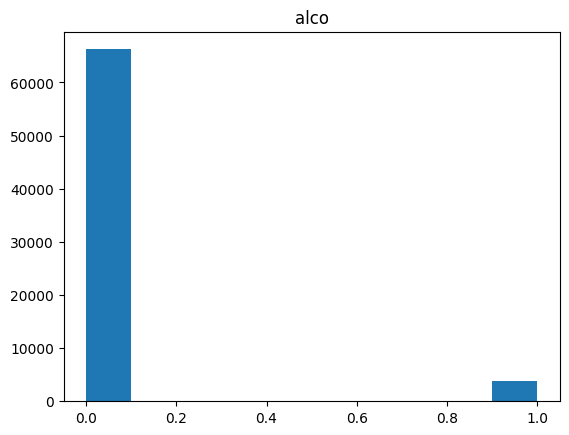

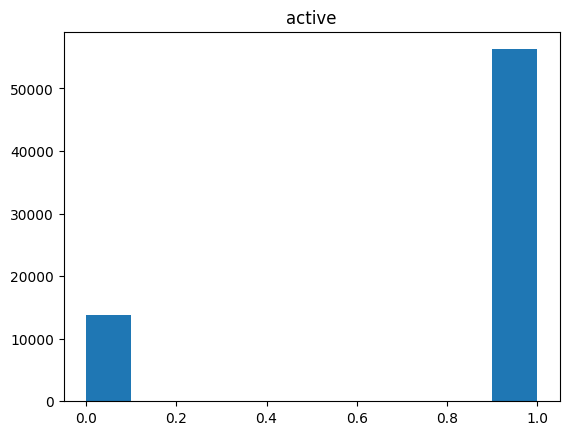

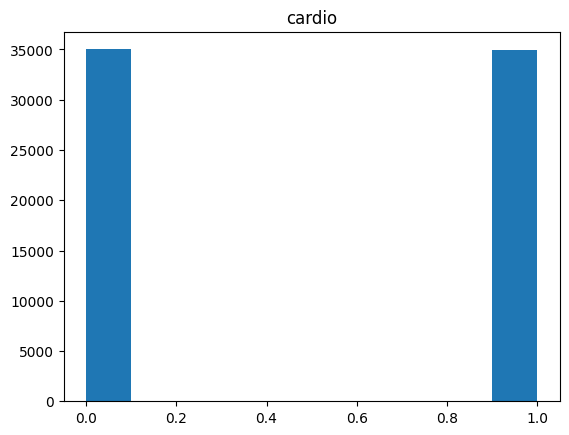

In [7]:
# Histogram Graph to view distribution of all the Columns

for i in data.columns:
    plt.hist(data[i])
    plt.title(i)
    plt.show()

**From Our Basic EDA, we can infer that:**
* Most of the patients were non-smokers and non-alcoholics
* Age is well distributed, slightly skewed towards left
* Gender is not well distributed, heavily right skewed

### Deeper insight

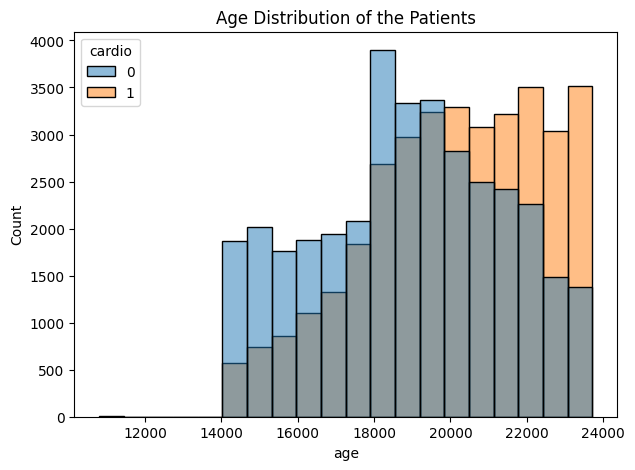

In [13]:
# Histogram of Age Distribution, with cardio at hue

plt.figure(figsize=(7,5))
sns.histplot(data=data, x='age', hue='cardio', bins=20)
plt.title("Age Distribution of the Patients")
plt.show()

In [14]:
# Smoking influence on having CVD in %

smoke_percent = pd.crosstab(data['smoke'], data['cardio'], normalize='index') * 100

smoke_percent.index = ['Non-Smoker', 'Smoker']
smoke_percent.columns = ['No CVD (%)', 'CVD (%)']

smoke_percent

,No CVD (%),CVD (%)
Non-Smoker,49.789287,50.210713
Smoker,52.520668,47.479332


In [15]:
# Drinking influence on having CVD in %

drinking_percent = pd.crosstab(data['alco'], data['cardio'], normalize='index') * 100

drinking_percent.index = ['Non-Drinker', 'Drinker']
drinking_percent.columns = ['No CVD (%)', 'CVD (%)']

drinking_percent

,No CVD (%),CVD (%)
Non-Drinker,49.942629,50.057371
Drinker,51.567481,48.432519


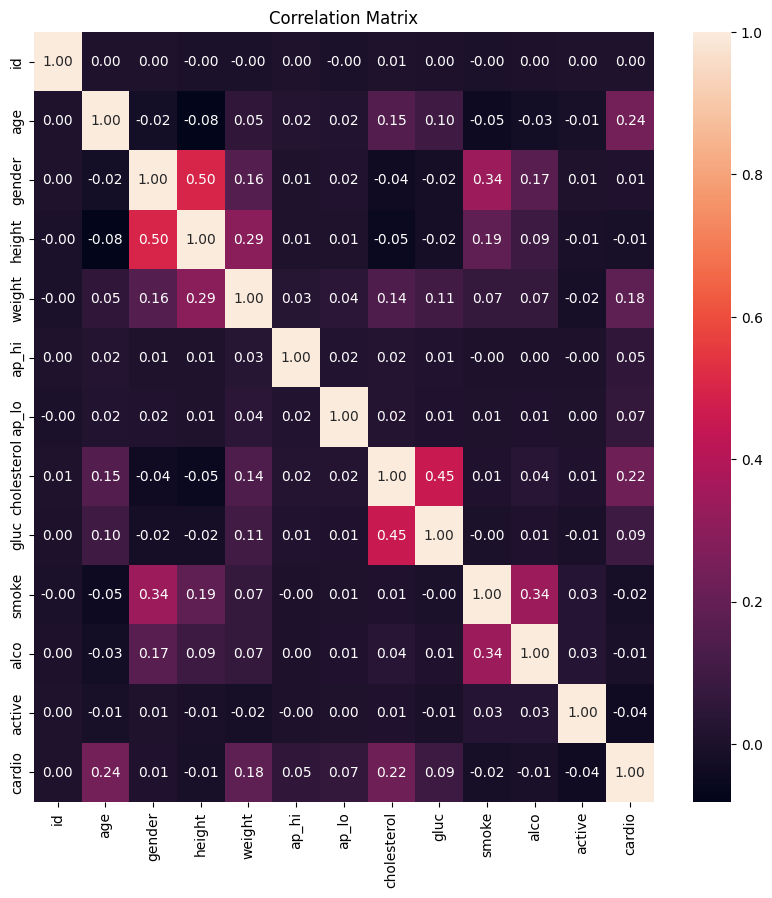

In [16]:
# Correlation Matrix

corr_mat = data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat, annot=True, fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

## Feature Engineering

In [17]:
# Removing id Column

data = data.drop('id', axis=1)

In [18]:
# Converting Age from Days to Years

data['age'] = (data['age']/365).astype(int)

In [19]:
# Converting Height from centimeters to meters

# data['height'] = (data['height']/100).astype(float)

## Training Model

In [20]:
# Splitting our data into X (features) and y (target)

X = data.drop('cardio', axis=1)
y = data['cardio']

In [21]:
X.shape, y.shape

((70000, 11), (70000,))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [23]:
# Put models in a dictionary

models = {"Logistic Regression" : LogisticRegression(),
          "Random Forest Classifer" : RandomForestClassifier(),
          "K-Nearest Neighbors Classifier" : KNeighborsClassifier()}

# Define a function fit and score our models

def fit_and_score(models, X_train, y_train, X_test, y_test):
    '''
    Fits and evaluates multiple models on train and testing data
    Parameter:
    ----------
    models: a dictionary of model names and instances
    X_train: training set features
    y_train: training set labels
    X_test: test set feature
    y_test: test set labels
    '''
    np.random.seed(42)
    model_scores = {}
    
    for model_name, model in models.items():
        # Fit the model on training sets
        model.fit(X_train, y_train)
        # Evalute the model and append it's score to model_score{}
        model_scores[model_name] = model.score(X_test, y_test)

    return model_scores

In [24]:
model_scores = fit_and_score(models=models, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
model_scores

/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7117142857142857,
 'Random Forest Classifer': 0.7057142857142857,
 'K-Nearest Neighbors Classifier': 0.6846428571428571}

**Proceeding with `Logistic Regression` as it performed the best with baseline parameters**

### GridSearchCV

In [26]:
lr = LogisticRegression(max_iter=5000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    # scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not c

Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.7195


In [28]:
# Training our model with best parameters

np.random.seed(42)
model = grid_search.best_estimator_
print(f"Model's Accuracy: {model.score(X_test, y_test)*100:.2f}")
print(f"Model's Precision: {model.score(X_test, y_test, )*100:.2f}")
print(f"Model's Accuracy: {model.score(X_test, y_test)*100:.2f}")

0.7235

## Model Evaluation

In [33]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73      6988
           1       0.75      0.68      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.73      0.72      0.72     14000

ROC AUC: 0.7861975757643043


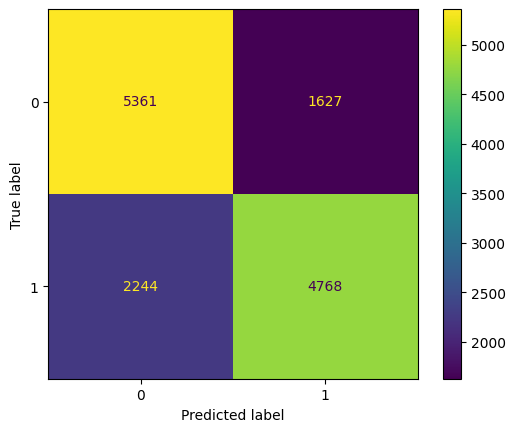

In [36]:
# Confusion Matrix

conf_matrix = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
conf_matrix.plot()
plt.show()

**Observations**
* CV Score = 71.95%
* Score = 72.35%
* Precision for Positive Class = 75%
* Recall for Positive Class = 68%
* F1 Score for Positive Class = 0.71
* ROC AUC = 0.78

## Exporting Our Model

In [34]:
import pickle

pickle.dump(model, open("../model/best_lr.pkl", "wb"))

# To load the model
# model = pickle.load(open("../model/best_lr.pkl", "rb"))